<a href="https://colab.research.google.com/github/katjanieberle/py_causal_modeling/blob/main/uplift_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install causalml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 21.6 MB/s eta 0:00:00


In [4]:
!pip install lightgbm

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

from causalml.dataset import synthetic_data

from lightgbm import LGBMRegressor

In [75]:
from causalml.inference.meta import LRSRegressor
from causalml.inference.meta import XGBTRegressor, MLPTRegressor
from causalml.inference.meta import BaseXRegressor
from causalml.inference.meta import BaseRRegressor
from xgboost import XGBRegressor

np.random.seed(251284)
y, X, treatment, tau, b, e = synthetic_data(mode=1, n=1000, p=5, sigma=1.0)
print(X)
X = pd.DataFrame(X, columns = ["x1","x2","x3","x4","x5"])
print(X.head(5))

[[0.91244365 0.95201052 0.04390208 0.27719213 0.04529609]
 [0.66756925 0.6861237  0.31665499 0.97225058 0.89909941]
 [0.88800455 0.58057192 0.86153626 0.93279691 0.34443787]
 ...
 [0.39266184 0.64889252 0.27446885 0.27139191 0.31554676]
 [0.21334383 0.32455535 0.08500998 0.46349947 0.79390051]
 [0.5567364  0.65353342 0.4525258  0.72498194 0.99342024]]
         x1        x2        x3        x4        x5
0  0.912444  0.952011  0.043902  0.277192  0.045296
1  0.667569  0.686124  0.316655  0.972251  0.899099
2  0.888005  0.580572  0.861536  0.932797  0.344438
3  0.355245  0.597925  0.469832  0.739894  0.829026
4  0.051282  0.667344  0.480959  0.237409  0.945609


In [76]:
true_ate = tau.mean()
print(f"Wahrer ATE: {true_ate:.4f}")

Wahrer ATE: 0.4915


In [55]:
# S Learner - Single learner - one model for all observations

lr = LRSRegressor()
te, lb, ub = lr.estimate_ate(X, treatment, y)
print('Average Treatment Effect (Linear Regression): {:.2f} ({:.2f}, {:.2f})'.format(te[0], lb[0], ub[0]))

# lb - lower bound confidence intervall
# ub - upper bound confidence intervall
# te - treatment effect


# Modell Warum
# Lineare Regression | Treatment-Koeffizient direkt = ATE
# Ridge / Lasso        | gut bei vielen Kovariaten
# XGBoost / Random Forest  | wenn Treatment-Effekt klein ist und nicht unterdrückt werden soll

# Problem beim S-Learner: Baummodelle können das Treatment-Feature ignorieren wenn es schwach ist — dann wird der Effekt unterschätzt.


Average Treatment Effect (Linear Regression): 0.75 (0.60, 0.90)


In [56]:
#from sklearn.linear_model import LinearRegression
#from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [57]:

# ─────────────────────────────────────────────
# Lineares Regressionsmodell trainieren
# y ~ X + treatment
# y - output is quantitative. If y - {0,1} - logistic regression
# ─────────────────────────────────────────────
# Intercept manuell hinzufügen (wie R es macht)

dff = pd.DataFrame(np.column_stack([y,X, treatment]), columns = ["y","x1","x2","x3","x4","x5","treatment"])
dff = sm.add_constant(dff)
print(dff)
dff["treatment"] = dff["treatment"].astype("category")

# Modell fitten
linreg = smf.ols("y ~ x1 + x2 + x3 + x4 + x5 + C(treatment)", data = dff).fit()

# Der Koeffizient von treatment wird dann genau so interpretiert wie in R: der erwartete Unterschied im Outcome zwischen Gruppe 1 und Gruppe 0, also direkt der ATE.
# R-style Summary
print(linreg.summary())

     const         y        x1        x2        x3        x4        x5  \
0      1.0 -0.886776  0.912444  0.952011  0.043902  0.277192  0.045296   
1      1.0  2.051560  0.667569  0.686124  0.316655  0.972251  0.899099   
2      1.0  2.050504  0.888005  0.580572  0.861536  0.932797  0.344438   
3      1.0  1.373844  0.355245  0.597925  0.469832  0.739894  0.829026   
4      1.0  0.239048  0.051282  0.667344  0.480959  0.237409  0.945609   
..     ...       ...       ...       ...       ...       ...       ...   
995    1.0 -0.600411  0.678679  0.059357  0.656121  0.636842  0.525148   
996    1.0  0.562045  0.625864  0.755567  0.967814  0.056894  0.068668   
997    1.0  3.569774  0.392662  0.648893  0.274469  0.271392  0.315547   
998    1.0  0.583973  0.213344  0.324555  0.085010  0.463499  0.793901   
999    1.0  1.748037  0.556736  0.653533  0.452526  0.724982  0.993420   

     treatment  
0          0.0  
1          1.0  
2          1.0  
3          1.0  
4          0.0  
..       

In [58]:
# T Learner - two models for observations

# Modell | Warum
# XGBoost / Random Forest   | kann komplexe nicht-lineare Effekte je Gruppe lernen
# Neural Networks | sehr flexible Modellierung pro Gruppe
# SVR | wenn Gruppen sehr unterschiedliche Strukturen haben

# Problem beim T-Learner: braucht genug Daten in beiden Gruppen — bei kleinen Gruppen instabil.
# Der T-Learner ist also eine Erweiterung des A/B Tests — er beantwortet nicht nur ob der Coupon wirkt, sondern für wen er am stärksten wirkt.


#XGBTRegressor:        Modell_0: y ~ X | T=0      (nur Kontrolle)
#                      Modell_1: y ~ X | T=1      (nur Treatment)

# 1. separate data in T=0, T=1
# 2. estimate XGBoost on T=1 and T=0 separately
# 3. predict for all persons BOTH outcomes (for T=1 and T=0)
# 4. colculate ITE (individual treatment effect) y1_hat - y0_hat
# 5. calculate ATE = average of ITE
# 6. confidence intervals via bootstrap, because no analytical formula for XGBoost
# Konfidenzintervall via Bootstrap — weil XGBoost kein analytisches KI liefert wie OLS, wird n=1000 mal neu gesampelt und der ATE neu berechnet. Das KI kommt aus der Verteilung dieser Bootstrap-ATEs.

xg = XGBTRegressor(random_state=42)
te, lb, ub = xg.estimate_ate(X, treatment, y)
print('Average Treatment Effect (XGBoost): {:.2f} ({:.2f}, {:.2f})'.format(te[0], lb[0], ub[0]))

Average Treatment Effect (XGBoost): 0.52 (0.45, 0.60)


In [59]:

# ─────────────────────────────────────────────
# Schritt 1: Zwei Modelle trainieren
# ─────────────────────────────────────────────
model_0 = XGBRegressor(random_state=42)
model_0.fit(X[treatment == 0], y[treatment == 0])   # E[Y | X, T=0]

model_1 = XGBRegressor(random_state=42)
model_1.fit(X[treatment == 1], y[treatment == 1])   # E[Y | X, T=1]

# ─────────────────────────────────────────────
# Schritt 2: Counterfactuals für alle vorhersagen
# ─────────────────────────────────────────────
y0_hat = model_0.predict(X)   # hypothetisches Y ohne Treatment
y1_hat = model_1.predict(X)   # hypothetisches Y mit Treatment

# ─────────────────────────────────────────────
# Schritt 3: ITE pro Person
# ─────────────────────────────────────────────
ite = y1_hat - y0_hat

df_results = pd.DataFrame({
    "y0_hat": y0_hat,
    "y1_hat": y1_hat,
    "ITE":    ite
})
print(df_results.head(10))

# ─────────────────────────────────────────────
# Schritt 4: ATE = Mittelwert der ITEs
# ─────────────────────────────────────────────
ate = np.mean(ite)
print(f"\nATE = {ate:.4f}")

     y0_hat    y1_hat       ITE
0 -0.890345  1.603820  2.494165
1  2.537557  2.080350 -0.457207
2  1.532466  2.058596  0.526130
3  1.724924  1.390969 -0.333955
4  0.233866  1.902728  1.668862
5  0.358790  1.096245  0.737455
6  1.042081  2.582414  1.540332
7  1.900800  1.462361 -0.438439
8  2.459077  1.026307 -1.432771
9  0.959290  1.839002  0.879711

ATE = 0.5230


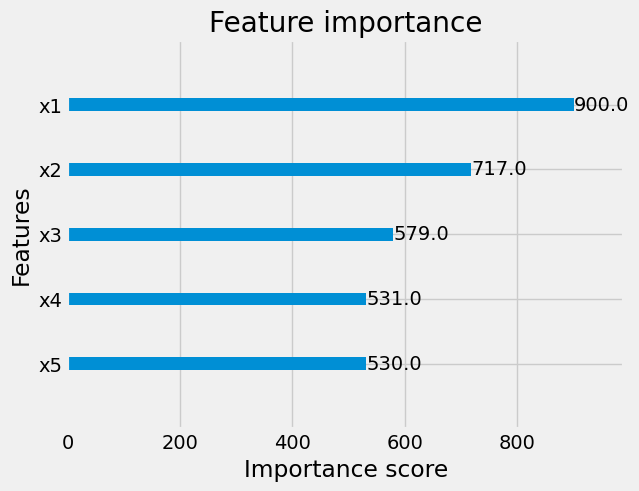

In [62]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model_0)
plt.show()

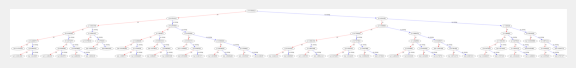

In [63]:
from xgboost import plot_tree

plot_tree(model_1, num_trees=0)   # ersten Baum anzeigen
plt.show()

In [64]:
booster = model_1.get_booster()
print(booster.get_dump()[0])   # erster Baum als Text

0:[x4<0.495496124] yes=1,no=2,missing=2
	1:[x2<0.355212212] yes=3,no=4,missing=4
		3:[x1<0.930147648] yes=7,no=8,missing=8
			7:[x5<0.610625565] yes=15,no=16,missing=16
				15:[x2<0.232686579] yes=31,no=32,missing=32
					31:leaf=-0.447443336
					32:[x2<0.290633321] yes=59,no=60,missing=60
						59:leaf=-0.0430115648
						60:leaf=-0.42129299
				16:[x5<0.832732975] yes=33,no=34,missing=34
					33:[x5<0.829025805] yes=61,no=62,missing=62
						61:leaf=-0.123061948
						62:leaf=0.28105703
					34:[x4<0.0497880951] yes=63,no=64,missing=64
						63:leaf=0.228039518
						64:leaf=-0.400361329
			8:[x1<0.959219337] yes=17,no=18,missing=18
				17:leaf=0.157084182
				18:[x1<0.97554636] yes=35,no=36,missing=36
					35:leaf=-0.0936222225
					36:leaf=0.0086129494
		4:[x5<0.287078559] yes=9,no=10,missing=10
			9:[x1<0.38938272] yes=19,no=20,missing=20
				19:[x4<0.0240862686] yes=37,no=38,missing=38
					37:leaf=-0.0129032852
					38:[x4<0.470481306] yes=65,no=66,missing=66
						65:leaf=-0.3

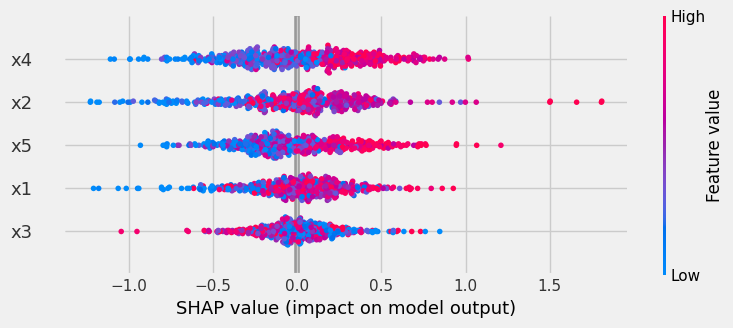

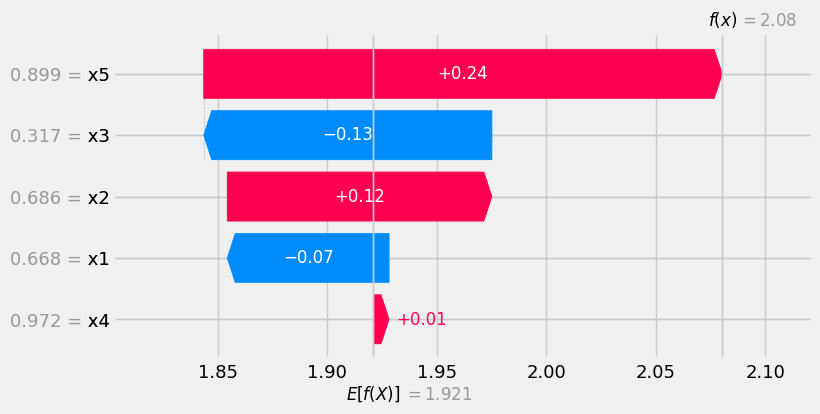

In [65]:
# ─────────────────────────────────────────────
# 5: SHAP-Werte — bester Weg um XGBoost zu verstehen
# erklärt für jede Person, warum das Modell diesen Wert vorhersagt
# ─────────────────────────────────────────────
import shap

explainer  = shap.Explainer(model_1)
shap_values = explainer(X[treatment == 1])

# Übersicht: welche Features treiben den Output?
shap.summary_plot(shap_values, X[treatment == 1])

# Eine einzelne Vorhersage erklären
shap.waterfall_plot(shap_values[0])

In [66]:
# T-Learner als neuronal network - MLP = Multilayer Perceptron
# Skalierung der Daten zwingend nötig
# lernt langsamer als XGBoost
# braucht nicht so viel Bootstrapping als XGBoost
# verhindert das overfitting besser
nn = MLPTRegressor(hidden_layer_sizes=(10, 10),
                 learning_rate_init=.1,
                 early_stopping=True,
                 random_state=42)
te, lb, ub = nn.estimate_ate(X, treatment, y)
print('Average Treatment Effect (Neural Network (MLP)): {:.2f} ({:.2f}, {:.2f})'.format(te[0], lb[0], ub[0]))

Average Treatment Effect (Neural Network (MLP)): 1.00 (0.87, 1.13)


In [ ]:
# X Learner
# Der X-Learner ist eine Erweiterung des T-Learners, entwickelt von Künzel et al. (2019). Er ist besonders stark wenn die Behandlungs- und Kontrollgruppe strukturell unterschiedlich und unterschiedlich groß sind.

In [67]:
xl = BaseXRegressor(learner=XGBRegressor(random_state=42))
te, lb, ub = xl.estimate_ate(X, treatment, y, e)
#                    e = Propensity Score = P(T=1 | X)
#                    Wahrscheinlichkeit dass Person behandelt wurde

print('Average Treatment Effect (BaseXRegressor using XGBoost): {:.2f} ({:.2f}, {:.2f})'.format(te[0], lb[0], ub[0]))

Average Treatment Effect (BaseXRegressor using XGBoost): 0.49 (0.44, 0.53)


In [ ]:
# Situation: Du schickst Kunden einen Rabatt-Coupon und willst wissen ob der Coupon den Kauf beeinflusst hat.

# Behandlungsgruppe:  alte VIP-Kunden    → kaufen sowieso viel
# Kontrollgruppe:     neue Gelegenheitskäufer → kaufen wenig

# Der beobachtete Umsatzunterschied kommt dann nicht vom Coupon — sondern davon dass die Gruppen von Anfang an völlig verschieden waren.

# das korrigiert Propensity score
#Kunde A: lang inaktiv, hoher Umsatz → treatment = 1, e = 0.95
#→ erwartbar behandelt
#→ ite = 0.95 * D0 + 0.05 * D1
#→ Kontrollmodell zählt stark   ← gut vergleichbar mit ähnlichen Kunden

#Kunde B: jung, niedriger Umsatz → treatment = 1, e = 0.05
#→ unerwartet behandelt — warum hat er den Coupon bekommen?
#→ ite = 0.05 * D0 + 0.95 * D1
#→ Kontrollmodell zählt kaum    ← kaum vergleichbare Kunden vorhanden

# Wenn du wenig über Kunden weißt, ist ein A/B-Test die einzige saubere Lösung — weil Randomisierung Confounding eliminiert ohne dass du die Confounder kennen musst.


In [ ]:
# Phase 1: Wie T-Learner — zwei Modelle trainieren
#         Modell_0: y ~ X | T=0
#         Modell_1: y ~ X | T=1

# Phase 2: Imputed Treatment Effects berechnen
#         D1 = y_treated  - Modell_0(X_treated)   ← echter Y minus counterfactual
#         D0 = Modell_1(X_control) - y_control     ← counterfactual minus echter Y

# Phase 3: Zwei weitere Modelle auf D1 und D0 trainieren
#         Modell_D1: D1 ~ X | T=1
#         Modell_D0: D0 ~ X | T=0

# Phase 4: ITE gewichtet kombinieren via Propensity Score e
#         ITE = e * Modell_D0(X) + (1-e) * Modell_D1(X)

In [73]:
from xgboost import XGBRegressor, XGBClassifier
from scipy import stats

# ─────────────────────────────────────────────
# Propensity Score schätzen
# e = P(T=1 | X) — falls nicht gegeben
# ─────────────────────────────────────────────
ps_model = XGBClassifier(random_state=42)
ps_model.fit(X, treatment)
e = ps_model.predict_proba(X)[:, 1]   # Wahrscheinlichkeit T=1

print("Propensity Score (erste 5):", e[:5].round(4))
print(f"Mittelwert e: {e.mean():.4f}  (erwartet ~0.5 bei 50/50 Zuweisung)")
# ─────────────────────────────────────────────
# Daten aufteilen
# ─────────────────────────────────────────────
X_control = X[treatment == 0];  y_control = y[treatment == 0]
X_treated = X[treatment == 1];  y_treated = y[treatment == 1]

print(f"\nKontrollgruppe:    n = {len(X_control)}")
print(f"Behandlungsgruppe: n = {len(X_treated)}")


# ─────────────────────────────────────────────
# PHASE 1: T-Learner — zwei Basismodelle
# identisch zum XGBTRegressor
# ─────────────────────────────────────────────
print("\n── Phase 1: Basismodelle trainieren ──")

model_0 = XGBRegressor(random_state=42)
model_0.fit(X_control, y_control)    # E[Y | X, T=0]

model_1 = XGBRegressor(random_state=42)
model_1.fit(X_treated, y_treated)    # E[Y | X, T=1]

print("Modell_0 und Modell_1 trainiert.")

# ─────────────────────────────────────────────
# PHASE 2: Imputed Treatment Effects
# Das ist der Kernunterschied zum T-Learner!
# ─────────────────────────────────────────────
print("\n── Phase 2: Imputed Treatment Effects ──")

# Für die behandelte Gruppe:
# echter Y minus was Modell_0 vorhergesagt hätte
D1 = y_treated - model_0.predict(X_treated)

# Für die Kontrollgruppe:
# was Modell_1 vorhergesagt hätte minus echter Y
D0 = model_1.predict(X_control) - y_control

print(f"D1 (treated):  mean = {D1.mean():.4f}, n = {len(D1)}")
print(f"D0 (control):  mean = {D0.mean():.4f}, n = {len(D0)}")


# ─────────────────────────────────────────────
# PHASE 3: Zwei weitere Modelle auf D1 und D0
# lernen den individuellen Effekt pro Gruppe
# ─────────────────────────────────────────────
print("\n── Phase 3: Effekt-Modelle trainieren ──")

model_D1 = XGBRegressor(random_state=42)
model_D1.fit(X_treated, D1)    # lernt ITE für Behandlungsgruppe

model_D0 = XGBRegressor(random_state=42)
model_D0.fit(X_control, D0)    # lernt ITE für Kontrollgruppe

print("Modell_D0 und Modell_D1 trainiert.")


# ─────────────────────────────────────────────
# PHASE 4: ITE gewichtet kombinieren
# Gewichtung via Propensity Score e
#
# ITE = e * D0_hat + (1-e) * D1_hat
#
# Intuition:
#   - wenn e hoch (Person wurde wahrscheinlich behandelt)
#     → vertraue mehr D0 (Kontrollgruppe-Modell)
#   - wenn e niedrig → vertraue mehr D1
# ─────────────────────────────────────────────
print("\n── Phase 4: Gewichtete Kombination ──")

D0_hat = model_D0.predict(X)   # ITE-Schätzung aus Kontrollmodell
D1_hat = model_D1.predict(X)   # ITE-Schätzung aus Behandlungsmodell

ite = e * D0_hat + (1 - e) * D1_hat

df_results = pd.DataFrame({
    "D0_hat": D0_hat.round(4),
    "D1_hat": D1_hat.round(4),
    "e":      e.round(4),
    "ITE":    ite.round(4)
})
print(df_results.head(10))


# ─────────────────────────────────────────────
# ATE = Mittelwert der ITEs
# ─────────────────────────────────────────────
ate = np.mean(ite)
print(f"\n── ATE (Punktschätzer) ──")
print(f"  te = {ate:.4f}  (wahrer Wert: 2.0)")


Propensity Score (erste 5): [0.0731 0.9734 0.9808 0.9479 0.0145]
Mittelwert e: 0.5027  (erwartet ~0.5 bei 50/50 Zuweisung)

Kontrollgruppe:    n = 497
Behandlungsgruppe: n = 503

── Phase 1: Basismodelle trainieren ──
Modell_0 und Modell_1 trainiert.

── Phase 2: Imputed Treatment Effects ──
D1 (treated):  mean = 0.6443, n = 503
D0 (control):  mean = 0.4002, n = 497

── Phase 3: Effekt-Modelle trainieren ──
Modell_D0 und Modell_D1 trainiert.

── Phase 4: Gewichtete Kombination ──
   D0_hat  D1_hat       e     ITE
0  2.4908  0.8526  0.0731  0.9723
1  0.0551 -0.4766  0.9734  0.0409
2 -0.0456  0.5151  0.9808 -0.0348
3  0.6322 -0.3426  0.9479  0.5815
4  1.6582  0.7496  0.0145  0.7629
5 -0.0363  0.7326  0.9163  0.0280
6  0.9684  1.5276  0.9936  0.9720
7 -0.4202  0.0843  0.1405  0.0134
8 -1.4407  0.0015  0.0096 -0.0124
9  0.8827  1.5612  0.0776  1.5086

── ATE (Punktschätzer) ──
  te = 0.4821  (wahrer Wert: 2.0)


In [ ]:
# für X learner kann man verschiedene Modelle nutzen
# Typische Kombinationen in der Praxis

# Outcome Modell (Phase 1) | Effekt Modell (Phase 3) | Wann
# XGBoost | XGBoost | Standard, schnell
# Random Forest |XGBoost |stabiler bei Rauschen
# Random Forest | Random Forest | wenig Daten
# XGBoost | MLP |komplexe Effektstruktur
# Linear Regression | XGBoost |lineares Outcome, nicht-linearer Effekt


# Wenig Daten        → Random Forest     (robuster, weniger Overfitting)
# Viel Daten         → XGBoost           (präziser, schneller)
# Komplexe Muster    → MLP               (flexibelste Funktion)
# Interpretierbarkeit → Linear Regression (Koeffizienten lesbar)

In [ ]:
# R Learner - arbeitet mit residuen
# double machine learning ansatz!

# Statt zwei getrennte Modelle zu trainieren, zieht er den Erwartungswert raus und arbeitet nur mit dem was übrig bleibt:

#Normales Modell:    y        = f(X) + τ(X) * T + ε
#R-Learner:         y - m(X) = τ(X) * (T - e(X)) + ε
#                   ↑              ↑
#              Outcome-Residuum  Treatment-Residuum

# m(X) = E[Y | X]         → erwarteter Outcome ohne Treatment-Info
# e(X) = E[T | X]         → Propensity Score (kennst du schon)
# τ(X) = ITE              → das wollen wir schätzen

# Phase 1a: Outcome-Modell
#          m(X) = E[Y | X]  → y auf X regressieren (ohne Treatment!)
#          Residuum: y_res = y - m(X)

# Phase 1b: Propensity-Modell
 #         e(X) = P(T=1 | X) → kennst du schon
 #         Residuum: t_res = T - e(X)

# Phase 2:  Effekt-Modell
 #         τ(X) schätzen durch:
 #         y_res / t_res ~ X
 #         → τ(X) * t_res ~ y_res

 # Der R-Learner gilt als robustester der vier — weil er als einziger beide Seiten (Outcome und Treatment) bereinigt bevor er den Effekt schätzt.

In [74]:
rl = BaseRRegressor(learner=XGBRegressor(random_state=42))
te, lb, ub =  rl.estimate_ate(X=X, p=e, treatment=treatment, y=y)
print('Average Treatment Effect (BaseRRegressor using XGBoost): {:.2f} ({:.2f}, {:.2f})'.format(te[0], lb[0], ub[0]))

Average Treatment Effect (BaseRRegressor using XGBoost): 3.34 (3.33, 3.35)


In [ ]:
# ─────────────────────────────────────────────
# Propensity Score (kennst du schon)
# ─────────────────────────────────────────────
ps_model = XGBClassifier(random_state=42)
ps_model.fit(X, treatment)
e = ps_model.predict_proba(X)[:, 1]


# ─────────────────────────────────────────────
# PHASE 1a: Outcome-Modell
# m(X) = E[Y | X] — ohne Treatment!
# ─────────────────────────────────────────────
print("── Phase 1a: Outcome-Modell ──")

outcome_model = XGBRegressor(random_state=42)
outcome_model.fit(X, y)           # NUR X, kein Treatment!
m_hat = outcome_model.predict(X)  # E[Y | X]

# Outcome-Residuum
y_res = y - m_hat

print(f"y_res Mittelwert: {y_res.mean():.4f}  (sollte ~0 sein)")
print(f"y_res Std:        {y_res.std():.4f}")


# ─────────────────────────────────────────────
# PHASE 1b: Treatment-Residuum
# t_res = T - e(X)
# ─────────────────────────────────────────────
print("\n── Phase 1b: Treatment-Residuum ──")

t_res = treatment - e

print(f"t_res Mittelwert: {t_res.mean():.4f}  (sollte ~0 sein)")
print(f"t_res Std:        {t_res.std():.4f}")


# ─────────────────────────────────────────────
# PHASE 2: Effekt-Modell
# Ziel: τ(X) schätzen
#
# Aus der Formel:
#   y_res = τ(X) * t_res + ε
#
# Umformen:
#   y_res / t_res = τ(X) + ε / t_res
#
# → Pseudo-Outcome = y_res / t_res
# → τ(X) auf Pseudo-Outcome regressieren
#    gewichtet mit t_res² (wichtige Beobachtungen stärker)
# ─────────────────────────────────────────────
print("\n── Phase 2: Effekt-Modell ──")

# Pseudo-Outcome
pseudo_outcome = y_res / t_res

# Gewichte: t_res² — Beobachtungen wo T klar 0 oder 1
# sind informativer als solche wo t_res ≈ 0
weights = t_res ** 2

print(f"Pseudo-Outcome (erste 5): {pseudo_outcome[:5].round(4)}")
print(f"Gewichte       (erste 5): {weights[:5].round(4)}")

# Effekt-Modell mit Gewichten trainieren
effect_model = XGBRegressor(random_state=42)
effect_model.fit(X, pseudo_outcome, sample_weight=weights)


# ─────────────────────────────────────────────
# ITE und ATE
# ─────────────────────────────────────────────
ite = effect_model.predict(X)
ate = np.mean(ite)

df_results = pd.DataFrame({
    "y_res":          y_res.round(4),
    "t_res":          t_res.round(4),
    "pseudo_outcome": pseudo_outcome.round(4),
    "ITE":            ite.round(4)
})
print("\n── Ergebnisse (erste 5) ──")
print(df_results.head())
print(f"\nATE = {ate:.4f}  (wahrer Wert: 2.0)")

In [ ]:
# Methode            | Paper | Journal | Jahr
# S/T/X-Learner | Künzel et al. | PNAS | 2019
# R-Learner     | Nie & Wager |Biometrika | 2021
# Double ML | Chernozhukov et al. |Econometrics Journal |2018
# Grundlage |Robinson |Econometrica | 1988

# Robinson, P.M. (1988). Root-N-consistent semiparametric regression. Econometrica, 56(4), 931–954.
# Nie, X., & Wager, S. (2017). Quasi-oracle estimation of heterogeneous treatment effects. Biometrika, 108(2), 299–213.
# Chernozhukov, V., et al. (2018). Double/debiased machine learning for treatment and structural parameters. The Econometrics Journal, 21(1), C1–C68.
# Künzel, S.R., Sekhon, J.S., Wager, S., & Yu, B. (2019). Metalearners for estimating heterogeneous treatment effects using machine learning. PNAS, 116(10), 4156–4165.